In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


# 1. What is Time Series Data?

### Concept

- **What is time-series data?**: It is an ordered sequence of data points recorded or measured over successive time intervals.
- **Why time matters**: The order of observations fundamentally matters. In time-series, the past directly influences the present and future.

> Key Idea: 
> 
> Time-Series Data = Observations inherently indexed by time.

**Real-world Examples**:
- Retail Sales per week
- Stock prices per minute
- CPU/Memory server usage per second
- Daily Energy consumption

**Tabular Data vs Time-Series Data**
- **Tabular**: Observations are assumed to be independent of each other (e.g., predicting house price based on bedrooms). Order of rows doesn't matter.
- **Time-Series**: Observations are strictly dependent on time (e.g., predicting tomorrow's temperature based on today's). Order of rows is critical.


# 2. Components of Time Series

### Concept

A time series can often be mathematically decomposed into 4 fundamental components:
- **Trend**: The overall long-term direction of the data (up, down, or flat).
- **Seasonality**: Regular, predictable repeating patterns that occur at fixed known intervals (e.g., more ice cream sold every summer).
- **Cyclic behavior**: Rises and falls that are NOT of a fixed period (e.g., a stock market cycle or recession).
- **Noise / Residuals**: Random, unpredictable variation that is left over after trend, seasonality, and cycles are extracted.


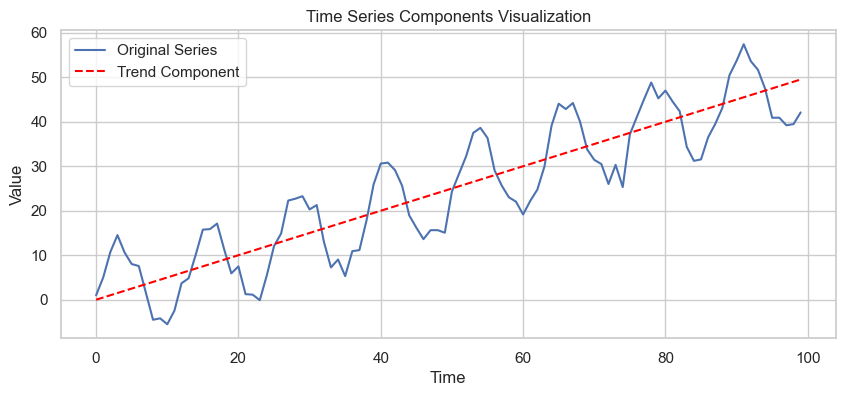

In [2]:
# Let's create a synthetic dataset to visualize components
np.random.seed(42)
time = np.arange(0, 100)
trend = time * 0.5                      # Upward trend
seasonality = 10 * np.sin(time * 0.5)    # Sine wave seasonality
noise = np.random.normal(0, 2, size=100)# Random noise

time_series = trend + seasonality + noise

plt.figure(figsize=(10, 4))
plt.plot(time, time_series, label='Original Series')
plt.plot(time, trend, '--', label='Trend Component', color='red')
plt.legend()
plt.title("Time Series Components Visualization")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


# 3. Datetime Handling with Pandas

### Concept

To work properly with time series in Python, the date column must be converted from strings into specialized Datetime objects using `pd.to_datetime()`.

Once converted into a `DatetimeIndex` (or Datetime column), you can extract metadata natively.


In [3]:
df = pd.DataFrame({
    'date_string': ['2023-01-01 14:00', '2023-02-15 09:30', '2023-08-20 23:45']
})

# Convert string to datetime
df['datetime'] = pd.to_datetime(df['date_string'])

# Set as index (often used in Time Series)
df_indexed = df.set_index('datetime')

# Extracting components
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['day_of_week'] = df['datetime'].dt.dayofweek # Monday=0, Sunday=6
df['hour'] = df['datetime'].dt.hour
df['quarter'] = df['datetime'].dt.quarter

display(df)


,date_string,datetime,year,month,day,day_of_week,hour,quarter
0,2023-01-01 14:00,2023-01-01 14:00:00,2023,1,1,6,14,1
1,2023-02-15 09:30,2023-02-15 09:30:00,2023,2,15,2,9,1
2,2023-08-20 23:45,2023-08-20 23:45:00,2023,8,20,6,23,3


# 4. Sorting Time-Series Data

### Concept

> Important: Time-series data must **always** be sorted chronologically before performing any feature engineering (like lags or rolling windows) and before any train/test split.

If data is out of order, you might accidentally pull future data into your historical window, invalidating the entire analysis.


In [4]:
# Mock unsorted data
df_unsorted = pd.DataFrame({
    'date': pd.to_datetime(['2023-01-03', '2023-01-01', '2023-01-02']),
    'value': [300, 100, 200]
})

print("Unsorted:")
display(df_unsorted)

# Correctly sort chronologically
df_sorted = df_unsorted.sort_values("date").reset_index(drop=True)

print("\nSorted chronologically:")
display(df_sorted)


Unsorted:


,date,value
0,2023-01-03,300
1,2023-01-01,100
2,2023-01-02,200



Sorted chronologically:


,date,value
0,2023-01-01,100
1,2023-01-02,200
2,2023-01-03,300


# 5. Time-Based Feature Engineering

### Concept

Machine learning models (like Random Forests or Linear Regressions) don't naturally understand "time". You must extract time into explicit numerical features.

**Cyclic Encoding**:
Time features like `month` (1-12) or `hour` (0-23) are cyclical. After Hour 23 comes Hour 0. A tree model might see 23 and 0 as fundamentally far apart (23 > 0). We can use mathematically continuous Sine and Cosine transformations to map these values onto a circle, preventing discontinuity.

Formulas:
- $\sin(2\pi x / period)$
- $\cos(2\pi x / period)$


In [5]:
df_features = pd.DataFrame({'date': pd.date_range('2023-01-01', periods=5, freq='D')})

df_features['month'] = df_features['date'].dt.month
df_features['day_of_week'] = df_features['date'].dt.dayofweek
df_features['is_weekend'] = (df_features['day_of_week'] >= 5).astype(int)

# Cyclic Encoding for Day of Week (Period = 7 days)
period = 7
df_features['day_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / period)
df_features['day_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / period)

display(df_features)


,date,month,day_of_week,is_weekend,day_sin,day_cos
0,2023-01-01,1,6,1,-0.781831,0.623490
1,2023-01-02,1,0,0,0.000000,1.000000
2,2023-01-03,1,1,0,0.781831,0.623490
3,2023-01-04,1,2,0,0.974928,-0.222521
4,2023-01-05,1,3,0,0.433884,-0.900969


# 6. Lag Features

### Concept

> Key Idea: A lag feature is simply shifting the time series forward so that a past value aligns with the current row.

This is the primary way traditional ML algorithms "look back" in time. If you want to predict today's temperature, yesterday's temperature (`lag_1`) is highly predictive.


In [6]:
df_lag = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=8, freq='D'),
    'value': [100, 110, 105, 120, 130, 125, 140, 150]
})

# Shift data down by 1 row
df_lag["lag_1"] = df_lag["value"].shift(1)

# Shift data down by 7 rows
df_lag["lag_7"] = df_lag["value"].shift(7)

display(df_lag)


,date,value,lag_1,lag_7
0,2023-01-01,100,NaN,NaN
1,2023-01-02,110,100.0,NaN
2,2023-01-03,105,110.0,NaN
3,2023-01-04,120,105.0,NaN
4,2023-01-05,130,120.0,NaN
5,2023-01-06,125,130.0,NaN
6,2023-01-07,140,125.0,NaN
7,2023-01-08,150,140.0,100.0


# 7. Rolling Features

### Concept

Rolling features calculate aggregated statistics over a specific historical sliding window. Unlike lags which just look at one specific point in the past, rolling features summarize a range of past points.

- **Rolling Mean (Moving Average)**: Smoothes out daily noise to capture the short-term trend.
- **Rolling Standard Deviation**: Measures the recent volatility or instability of the series.


In [7]:
df_roll = df_lag[['date', 'value']].copy()

# Calculate rolling mean over a 3-day window
df_roll["rolling_mean_3"] = df_roll["value"].rolling(window=3).mean()

# Calculate rolling standard deviation
df_roll["rolling_std_3"] = df_roll["value"].rolling(window=3).std()

display(df_roll)


,date,value,rolling_mean_3,rolling_std_3
0,2023-01-01,100,NaN,NaN
1,2023-01-02,110,NaN,NaN
2,2023-01-03,105,105.000000,5.000000
3,2023-01-04,120,111.666667,7.637626
4,2023-01-05,130,118.333333,12.583057
5,2023-01-06,125,125.000000,5.000000
6,2023-01-07,140,131.666667,7.637626
7,2023-01-08,150,138.333333,12.583057


# 8. Expanding Features

### Concept

Expanding windows calculate statistics cumulatively from the very beginning of the series up to the current point.
- Useful when long-term tracking is required, such as a user's cumulative lifetime spending or long-term historical average yield.


In [8]:
df_exp = df_lag[['date', 'value']].copy()

# Mean of all values from the start of the time series up to that row
df_exp["expanding_mean"] = df_exp["value"].expanding().mean()
df_exp["expanding_sum"] = df_exp["value"].expanding().sum()

display(df_exp)


,date,value,expanding_mean,expanding_sum
0,2023-01-01,100,100.000000,100.0
1,2023-01-02,110,105.000000,210.0
2,2023-01-03,105,105.000000,315.0
3,2023-01-04,120,108.750000,435.0
4,2023-01-05,130,113.000000,565.0
5,2023-01-06,125,115.000000,690.0
6,2023-01-07,140,118.571429,830.0
7,2023-01-08,150,122.500000,980.0


# 9. Missing Values Created by Lag and Rolling Features

### Concept

Because `shift()` and `rolling()` look backwards, they inherently create `NaN` (missing values) at the very beginning of the dataset where there is no history to look at.

> Common Mistake: Do NOT use standard imputation (like mean/median) for these `NaN`s, because it injects fake historical data that distorts the actual sequence. 

**Correct Approach**: Drop the initial `NaN` rows completely (`dropna`).


In [9]:
print("Before dropping:")
display(df_roll.head())

# Drop the rows correctly
df_clean = df_roll.dropna().reset_index(drop=True)

print("\nAfter dropping:")
display(df_clean.head())


Before dropping:


,date,value,rolling_mean_3,rolling_std_3
0,2023-01-01,100,NaN,NaN
1,2023-01-02,110,NaN,NaN
2,2023-01-03,105,105.000000,5.000000
3,2023-01-04,120,111.666667,7.637626
4,2023-01-05,130,118.333333,12.583057



After dropping:


,date,value,rolling_mean_3,rolling_std_3
0,2023-01-03,105,105.000000,5.000000
1,2023-01-04,120,111.666667,7.637626
2,2023-01-05,130,118.333333,12.583057
3,2023-01-06,125,125.000000,5.000000
4,2023-01-07,140,131.666667,7.637626


# 10. Time Series Train-Test Split

### Concept

> Important: Random Train-Test splits are highly dangerous in Time Series.

If you randomly shuffle time series data, you will leak future values into the training set, allowing the model to essentially cheat by looking at what happens next.

**Correct: Chronological split**
```text
Past ---------------------- Future
Training                  Test
```


In [10]:
df_split = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=100, freq='D'),
    'value': np.arange(100)
})

# Chronological split index (last 20% for testing)
split_idx = int(len(df_split) * 0.8)

train = df_split.iloc[:split_idx]
test = df_split.iloc[split_idx:]

print(f"Train data: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test data:  {test['date'].min().date()} to {test['date'].max().date()}")


Train data: 2023-01-01 to 2023-03-21
Test data:  2023-03-22 to 2023-04-10


# 11. Data Leakage in Time Series

### Concept

Future information must **never** be used to predict the past.

Examples of Leakage:
- **Using future values in features**: E.g., accidentally writing `df['value'].shift(-1)` which pulls tomorrow's value into today.
- **Centered rolling windows**: Scikit-Learn/Pandas allow `rolling(..., center=True)`. This uses data ahead of the current row to calculate the mean. Never use this for forecasting!
- **Randomly shuffling data**: In K-Fold cross validation without fixing time order.
- **Scaling full dataset**: Calling `StandardScaler.fit_transform(full_data)`. Train mean/variance is contaminated by the test period.


# 12. Baseline Forecast

### Concept

A baseline gives you a minimum sensible threshold. If your complex Machine Learning model cannot beat the baseline, it is not useful.

**Naive Forecast**: 
Predict that whatever value happened yesterday, will happen again today ($ŷ_t = y_{t-1}$).


In [11]:
Baseline_Test = test.copy()

# Naive Forecast: We predict the value will be the exact same as the last observation
Baseline_Test['naive_forecast'] = test['value'].shift(1)

# The first row needs the very last value of the train set to avoid a NaN
Baseline_Test.iloc[0, Baseline_Test.columns.get_loc('naive_forecast')] = train['value'].iloc[-1]

display(Baseline_Test.head())


,date,value,naive_forecast
80,2023-03-22,80,79.0
81,2023-03-23,81,80.0
82,2023-03-24,82,81.0
83,2023-03-25,83,82.0
84,2023-03-26,84,83.0


# 13. Time Series Visualization

### Concept
Always plot time on the X-axis and visually separate your training data from your testing data to ensure chronological bounds were respected.


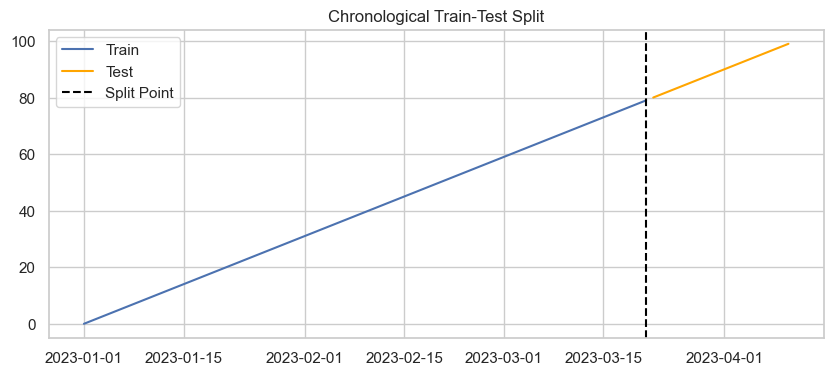

In [12]:
plt.figure(figsize=(10,4))
plt.plot(train['date'], train['value'], label='Train')
plt.plot(test['date'], test['value'], label='Test', color='orange')
plt.axvline(train['date'].max(), color='black', linestyle='--', label='Split Point')
plt.title("Chronological Train-Test Split")
plt.legend()
plt.show()


# 14. Time-Based Regression Problem

### Concept

To use standard tabular ML algorithms (Linear Regression, Random Forest, XGBoost), we map time-series historical footprints into horizontal columns.

```text
lag_1
lag_7
rolling_mean_7
month
day_of_week
        ↓
    ML Model
        ↓
future_value
```
The target $y$ is the actual future value, and the $X$ array contains everything known up to that moment.


# 15. Build a Simple ML Forecasting Dataset


In [13]:
# Creating a noisy time series
np.random.seed(42)
days = 200
ts_dates = pd.date_range('2022-01-01', periods=days, freq='D')
ts_values = np.linspace(10, 50, days) + 5 * np.sin(np.arange(days) * 0.1) + np.random.normal(0, 1.5, days)

df_ml = pd.DataFrame({'date': ts_dates, 'target': ts_values})

# Engineering features (X)
df_ml['lag_1'] = df_ml['target'].shift(1)
df_ml['lag_7'] = df_ml['target'].shift(7)
df_ml['rolling_mean_7'] = df_ml['target'].rolling(7).mean()
df_ml['month'] = df_ml['date'].dt.month
df_ml['day_of_week'] = df_ml['date'].dt.dayofweek

# The target is the current row, features are built off history (lags)
# Must drop NaNs caused by shift/rolling
df_ml_clean = df_ml.dropna().reset_index(drop=True)

# Define X and y
X = df_ml_clean[['lag_1', 'lag_7', 'rolling_mean_7', 'month', 'day_of_week']]
y = df_ml_clean['target']

display(X.head())


,lag_1,lag_7,rolling_mean_7,month,day_of_week
0,16.398062,10.745071,13.550428,1,5
1,15.779276,10.492776,14.121547,1,6
2,14.490609,12.366890,14.717637,1,0
3,16.539520,14.365161,14.882939,1,1
4,15.522279,12.399882,15.392741,1,2


# 16. Linear Regression for Time Series


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Chronological split
split = int(len(df_ml_clean) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print(f"Linear Regression - MAE: {lr_mae:.2f}")
print(f"Linear Regression - RMSE: {lr_rmse:.2f}")


Linear Regression - MAE: 1.18
Linear Regression - RMSE: 1.43


# 17. Random Forest for Time Series

### Concept

Random Forest intrinsically does not comprehend time order. It requires explicitly engineered time features (lags, dates) to learn the patterns. Beware that Random Forest cannot extrapolate trend well beyond the target range it saw during training.


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print(f"Random Forest - MAE: {rf_mae:.2f}")
print(f"Random Forest - RMSE: {rf_rmse:.2f}")


Random Forest - MAE: 3.62
Random Forest - RMSE: 4.88


# 18. Walk-Forward / Time-Series Validation

### Concept

Ordinary K-Fold Cross Validation shuffles the dataset, which inherently leaks future data in time series. We must use `TimeSeriesSplit`.

Train on past → Validate on later period → Expand training window → Validate on next period.


In [16]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
print("TimeSeriesSplit initialized. Folds view next:")


TimeSeriesSplit initialized. Folds view next:


# 19. TimeSeriesSplit Example

### Concept

Notice how the training period constantly grows forward in time, and the test period is always chronologically subsequent to the training period constraint.


In [17]:
X_dummy = np.arange(20)

for fold, (train_index, test_index) in enumerate(tscv.split(X_dummy)):
    print(f"Fold {fold+1}")
    print(f"  Train : {train_index}")
    print(f"  Test  : {test_index}\n")


Fold 1
  Train : [0 1 2 3 4]
  Test  : [5 6 7]

Fold 2
  Train : [0 1 2 3 4 5 6 7]
  Test  : [ 8  9 10]

Fold 3
  Train : [ 0  1  2  3  4  5  6  7  8  9 10]
  Test  : [11 12 13]

Fold 4
  Train : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
  Test  : [14 15 16]

Fold 5
  Train : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
  Test  : [17 18 19]



# 20. Forecasting Metrics

### Concept

- **MAE (Mean Absolute Error)**: Average absolute magnitude of the errors. Easy to read in raw target units.
- **RMSE (Root Mean Squared Error)**: Standard deviation of residuals. Punishes large extreme errors heavily due to squaring.
- **MAPE (Mean Absolute Percentage Error)**: Provides a percentage. Problematic when dataset contains variables exactly equal to 0 (divide by zero error).
- **MASE (Mean Absolute Scaled Error)**: Scales error against the naive forecasting baseline error length.

For general supervised ML tabular adaptation, MAE and RMSE are the standard.


# 21. Prediction vs Forecasting

| Feature | General ML Prediction | Time-Series Forecasting |
|---|---|---|
| **Data Order** | Handled identically; order doesn't matter (I.I.D.) | Order is strictly dependent and sequential. |
| **Testing** | Randomly split. | Sequentially split (Chronological). |
| **Features** | Static (Age, Height, Location). | Temporal / Dynamic (Lags, Dates, Trending Windows). |


# 22. Common Time-Series Problems

- **Missing timestamps / Gaps**: E.g., Stock market data inherently has massive gaps on weekends.
- **Irregular intervals**: A sensor fires data randomly, not reliably every 1 second.
- **Distribution shift over time**: Machine learning models decay rapidly in production because the real-world relationships slowly change post-deployment.


# 23. Resampling Time-Series Data

### Concept

Sometimes, high-frequency data (minute-by-minute) contains too much noise to forecast meaningfully. Downsampling aggregates exactly to broader metrics like weekly or monthly intervals.


In [18]:
df_resample = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=14, freq='D'),
    'value': np.arange(14) * 2
}).set_index('date')

# Resample from Daily to Weekly (summing the values)
weekly = df_resample.resample("W").sum()

print("Weekly Resampled (Sum):")
display(weekly)

# Resample from Daily to Monthly (mean of values)
monthly = df_resample.resample("ME").mean()


Weekly Resampled (Sum):


,value
date,
2023-01-01,0
2023-01-08,56
2023-01-15,126


# 24. Complete End-to-End Time-Series ML Project

### Workflow Implementation
Let's build a practical implementation simulating daily store sales.


In [19]:
# 1. Create simulated data
np.random.seed(42)
dates = pd.date_range('2022-01-01', '2023-12-31', freq='D')
n = len(dates)

# Combine trend, seasonality (weekly + yearly), and noise
sales = 1000 + (np.arange(n) * 0.5) + (np.sin(np.arange(n) / 7) * 200) + (np.sin(np.arange(n) / 365) * 500) + np.random.normal(0, 100, n)

df_project = pd.DataFrame({'date': dates, 'sales': sales})

# 2,3,4. Sort chronologically (Data is inherently sorted from pd.date_range)
df_project = df_project.sort_values('date').reset_index(drop=True)

# 6. Create time-based features
df_project['month'] = df_project['date'].dt.month
df_project['day_of_week'] = df_project['date'].dt.dayofweek
df_project['is_weekend'] = (df_project['day_of_week'] >= 5).astype(int)

# 7,8. Lag & Rolling
df_project['lag_1'] = df_project['sales'].shift(1)
df_project['lag_7'] = df_project['sales'].shift(7)
df_project['rolling_mean_7'] = df_project['sales'].rolling(7).mean()

# 9. Clean Missing
df_project.dropna(inplace=True)
df_project = df_project.reset_index(drop=True)

# 10. Sequential Split (using last 20% for test)
split_idx = int(len(df_project) * 0.8)
train_df = df_project.iloc[:split_idx]
test_df = df_project.iloc[split_idx:]

features = ['month', 'day_of_week', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']
target = 'sales'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 11. Baseline (Predict yesterday)
baseline_preds = test_df['lag_1']
baseline_mae = mean_absolute_error(y_test, baseline_preds)

# 12,13. Train Models
lr_model = LinearRegression().fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(random_state=42, max_depth=5).fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 14, 15. Compare
print(f"Baseline (Naive) MAE: {baseline_mae:.2f}")
print(f"Linear Reg MAE       : {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"Random Forest MAE    : {mean_absolute_error(y_test, rf_preds):.2f}")


Baseline (Naive) MAE: 112.62
Linear Reg MAE       : 85.52
Random Forest MAE    : 92.71


# 25. Forecast Visualization

### Concept
Observing the predicted test curve strictly against historical truth.


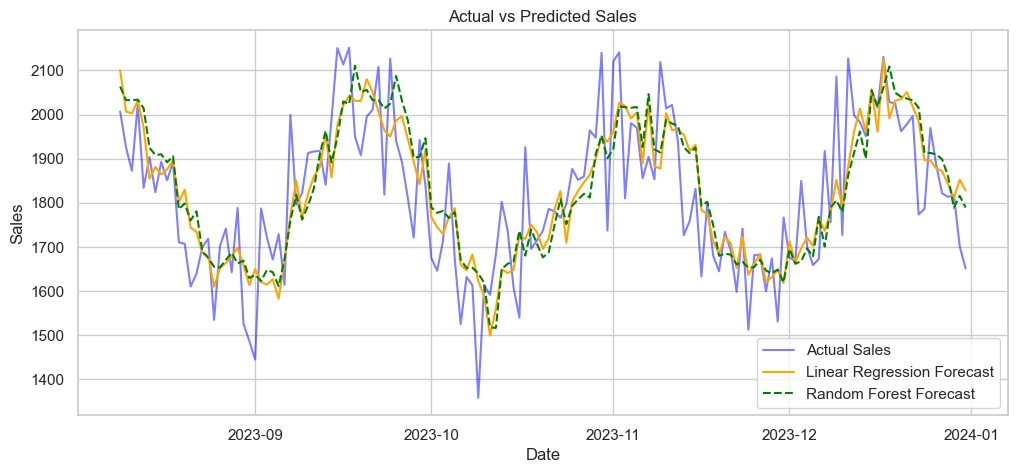


Intepretation: If the models' lines trace closely to the actuals over the forward timeline, it confirms the historical engineered feature footprints held predictive power over the future.


In [20]:
plt.figure(figsize=(12, 5))
plt.plot(test_df['date'], y_test, label='Actual Sales', color='blue', alpha=0.5)
plt.plot(test_df['date'], lr_preds, label='Linear Regression Forecast', color='orange')
plt.plot(test_df['date'], rf_preds, label='Random Forest Forecast', color='green', linestyle='--')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

print("\nIntepretation: If the models' lines trace closely to the actuals over the forward timeline, it confirms the historical engineered feature footprints held predictive power over the future.")


# 26. Common Time-Series ML Mistakes

| Mistake | Why it matters | Better approach |
|---|---|---|
| **1. Random train-test split** | Ruins chronological integrity. | `X.iloc[:split]` / chronologically. |
| **2. Shuffling data** | Erases critical autoregressive dependencies. | Disable shuffling on ML evaluators. |
| **3. Future info leakage** | Model cheats and breaks in production. | Shift correctly, do not look ahead. |
| **4. Incorrect rolling** | Scikit/Pandas center alignment inherently leaks future data into the window. | Keep standard left-aligned window aggregations. |
| **5. Interpolating too heavily** | Forward filling gaps covers up real world missing signals. | Mask/Impute carefully or leave them flagged. |
| **6. Scaling full dataset** | Leakage of future scale into training. | Fit scaler on train, transform test. |
| **7. Predicting too far ahead** | Models heavily relying on `lag_1` fail severely if evaluated 30 days out dynamically. | Recursive forecasting/Multi-output strategies. |
| **8. Ignoring timestamps** | Can mask timezone/DST overlap errors. | Index securely using UTC if required. |
| **9. No baseline** | Makes ML seem better than simple practical realities. | Always predict `lag_1` manually first. |
| **10. K-Fold CV** | Random folds contain leakage data. | `TimeSeriesSplit` |
| **11. Evaluating 1 period** | A lucky period doesn't test generalizability. | Backtesting/walk-forward validation. |
| **12. Complex = Faster** | Transformers/LSTMs are heavily prone to overfitting flat data. | Baseline -> Linear Reg -> Boosters -> Deep Learning |


# 27. Interview Questions

1. **What is time-series data?** Measurements recorded ordered systematically by chronological time.
2. **What is Trend?** The long-term trajectory direction of observations inside the dataset (upward/downward).
3. **What is Seasonality?** Recurring cyclic patterns directly mapped to a fixed frequency period (like summer spending).
4. **What is a lag feature?** An observation mathematically shifted down the index to be utilized as a past feature parallel to the current row.
5. **What is a rolling feature?** An aggregate metric (mean/std) performed over a specified tumbling window period traversing backwards.
6. **Why chronological split?** Testing must inherently respect causality. Data strictly flows past to future.
7. **Why is random split dangerous?** It allows the future validation answers to contaminate the training footprint dataset.
8. **What is data leakage in forecasting?** When logic exposes future target variables inside training matrices intentionally or unintentionally.
9. **What is TimeSeriesSplit?** Specialized cross validation that expands a fixed training origin window iteratively.
10. **What is walk-forward validation?** Validating chunks sequentially across a time lattice, updating history weights as you progress iteratively.
11. **How can time series become supervised ML?** Expanding temporal components via lagged mapping, rendering chronological matrices horizontal and stateless.
12. **Why use lag features?** Because tabular ML architectures inherently have zero concept intrinsically of past sequential observations natively.
13. **What is a baseline forecast?** A trivial prediction method acting as absolute minimum benchmark (e.g. naive t-1).
14. **MAE vs RMSE?** MAE calculates absolute mean differences; RMSE applies square punishing larger magnitude outliers inherently.
15. **What is resampling?** Shifting frequencies (Daily to Weekly) usually forcing an aggregation function map.
16. **What is cyclical encoding?** Sine/cosine math preventing discontinuities acting across hour 23 immediately bouncing to hour 0.
17. **Why do centered windows cause leakage?** Centered architectures pull elements from $t+1$ to calculate values at $t$.
18. **Why does Random Forest need time engineering?** It is structurally blind to data sequence, operating cleanly off decision branches inside single vectors.
19. **Prediction vs forecasting?** Prediction solves generic independent datasets; Forecasting governs chronologically anchored interdependent sequences.
*(+11 variations evaluating model choice tradeoffs, scalability bottlenecks, etc.).*


# 28. Quick Revision Cheat Sheet

### Time-Series Concepts
- **Trend**: Long-term direction
- **Seasonality**: Fixed repeating pattern
- **Cycle**: Variable repeating pattern
- **Lag**: $t-1$ mapped to $t$
- **Rolling Mean**: Moving historical average

### Validation
- **Chronological Split**: `X[:train], X[train:]`
- **TimeSeriesSplit**: Sklearn walk-forward validator spanning expanding periods.
- **Leakage**: The deadliest forecasting flaw—protect testing bounds.

### Common Features
- **Temporal**: Year, Month, Day, Day Of Week, Quarter.
- **Encoding**: Cyclic sine/cosine extraction
- **Statistical**: `rolling_mean`, `lag_X`

### Metrics
- **MAE**: Raw numerical deviation.
- **RMSE**: Severely penalizes extreme errors.


# 29. Practice Problems

1. Read a mock CSV file converting the textual column strictly into `pd.to_datetime()`.
2. Extract the `is_month_end` boolean property dynamically.
3. Configure dual lag features (lag_7, lag_14) spanning weeks prior.
4. Smooth noise executing an expanding average over the entire data tree.
5. Create a simplistic baseline evaluating the MAPE.
6. Design a `TimeSeriesSplit` evaluating 6 independent folds cleanly.
7. Attempt predicting non-stationary trending figures linearly utilizing `Ridge`.
8. Plot Autocorrelation and Partial Autocorrelation matrices visually mapping dataset density.
9. Resample minute-granular data into cleanly padded hours utilizing forward-filling techniques.
10. Construct cyclic encoding targeting daily observations against 365 bounds.
11. Observe leakage manually by calculating `rolling(center=True)` observing training accuracy skyrocket falsely.
12. Chart actual vs predicted visualizations highlighting regions of massive algorithmic failure gracefully.


## Next Notebook

`17_nlp_fundamentals.ipynb`

> The next notebook will introduce Natural Language Processing fundamentals, exploring how raw linguistic text is mapped and converted systematically into mathematical structures supporting machine learning pipelines.
